In [28]:
import pandas as pd
import numpy as np
import nltk
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [2]:

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\minus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\minus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\minus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:

# Load dataset from files
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")
fake_df["label"] = 0
true_df["label"] = 1
df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)

print("Raw Dataset Sample:")
print(df[["text", "label"]].head())


Raw Dataset Sample:
                                                text  label
0  Donald Trump just couldn t wish all Americans ...      0
1  House Intelligence Committee Chairman Devin Nu...      0
2  On Friday, it was revealed that former Milwauk...      0
3  On Christmas day, Donald Trump announced that ...      0
4  Pope Francis used his annual Christmas Day mes...      0


In [4]:

# Text Preprocessing
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
print("Cleaned Text Sample:")
print(df[['text', 'clean_text']].head())


Cleaned Text Sample:
                                                text  \
0  Donald Trump just couldn t wish all Americans ...   
1  House Intelligence Committee Chairman Devin Nu...   
2  On Friday, it was revealed that former Milwauk...   
3  On Christmas day, Donald Trump announced that ...   
4  Pope Francis used his annual Christmas Day mes...   

                                          clean_text  
0  donald trump wish american happy new year leav...  
1  house intelligence committee chairman devin nu...  
2  friday revealed former milwaukee sheriff david...  
3  christmas day donald trump announced would bac...  
4  pope francis used annual christmas day message...  


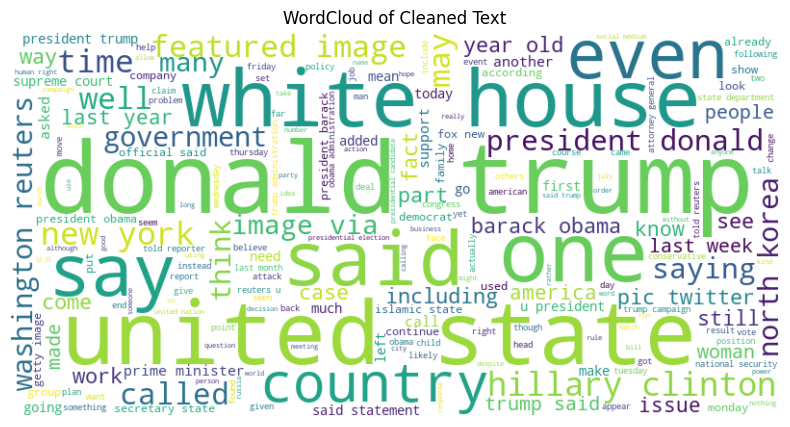

In [5]:

# WordCloud
all_words = ' '.join([text for text in df['clean_text']])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Cleaned Text")
plt.show()


In [6]:

# Tokenization and Padding
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded = pad_sequences(sequences, maxlen=100)


In [20]:
import pickle
# Save tokenizer
with open("Models/tokenizer.pickle", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [7]:

# Train-test split
X = padded
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Load or Train Model
model_path = "Models/fakenews_model.h5"
if os.path.exists(model_path):
    print("Loading existing model...")
    model = load_model(model_path)
else:
    print("Training new model...")
    model = Sequential()
    model.add(Embedding(input_dim=5000, output_dim=64))
    model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
    model.save(model_path)
    print("Model saved to fakenews_model.h5")

print("Model training complete.")
acc = model.evaluate(X_test, y_test)[1]
print(f"Test Accuracy: {acc*100:.2f}%")


Training new model...
Epoch 1/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 134s 240ms/step - accuracy: 0.9214 - loss: 0.2367 - val_accuracy: 0.9722 - val_loss: 0.0819
Epoch 2/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 94s 185ms/step - accuracy: 0.9806 - loss: 0.0587 - val_accuracy: 0.9772 - val_loss: 0.0730
Epoch 3/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 99s 195ms/step - accuracy: 0.9879 - loss: 0.0387 - val_accuracy: 0.9802 - val_loss: 0.0729
Epoch 4/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 75s 149ms/step - accuracy: 0.9925 - loss: 0.0255 - val_accuracy: 0.9839 - val_loss: 0.0630
Epoch 5/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 83s 151ms/step - accuracy: 0.9927 - loss: 0.0240 - val_accuracy: 0.9794 - val_loss: 0.0730


Model saved to fakenews_model.h5
Model training complete.
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9804 - loss: 0.0774
Test Accuracy: 98.13%


In [13]:
import keras
keras.saving.save_model(model, 'Models/my_model.keras')

In [22]:

# Text Prediction
input_text = input("Enter News Text to Predict: ")
if input_text:
    cleaned = clean_text(input_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded_seq = pad_sequences(seq, maxlen=100)
    prediction = model.predict(padded_seq)[0][0]
    label = "FAKE" if prediction < 0.5 else "REAL"
    print(f"Prediction: {label} ({prediction:.2f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Prediction: REAL (1.00)


## Fake Article

NASA Confirms Earth Will Experience 15 Days of Darkness in July

In a press conference held earlier today, NASA officials announced that Earth will be plunged into total darkness for 15 consecutive days starting July 15, due to an astronomical event involving Jupiter and Venus. Scientists claim this rare alignment will block 90% of sunlight, triggering temporary darkness across the globe. The phenomenon, known as “The Alignment of the Centuries,” is expected to disrupt communication systems and power grids.

Social media has erupted with users sharing tips on how to prepare for the blackout. NASA urges people to stay calm and stock up on essentials. Meanwhile, conspiracy theorists are linking the event to ancient prophecies.


## True Article

Prime Minister Narendra Modi is scheduled to visit Odisha this afternoon to attend the state-level function at Janata Maidan in Bhubaneswar to commemorate the completion of one year of the first BJP government in Odisha led by Chief Minister Mohan Charan Majhi.


In [23]:
y_true = df['label']
y_pred = (model.predict(X) > 0.5).astype(int)


1404/1404 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step


In [24]:

report = classification_report(y_true, y_pred, output_dict=True)
print("\nClassification Report:")
print(pd.DataFrame(report).transpose())



Classification Report:
              precision    recall  f1-score       support
0              0.993690  0.992505  0.993097  23481.000000
1              0.991793  0.993090  0.992441  21417.000000
accuracy       0.992784  0.992784  0.992784      0.992784
macro avg      0.992741  0.992797  0.992769  44898.000000
weighted avg   0.992785  0.992784  0.992784  44898.000000



Confusion Matrix:
[[23305   176]
 [  148 21269]]


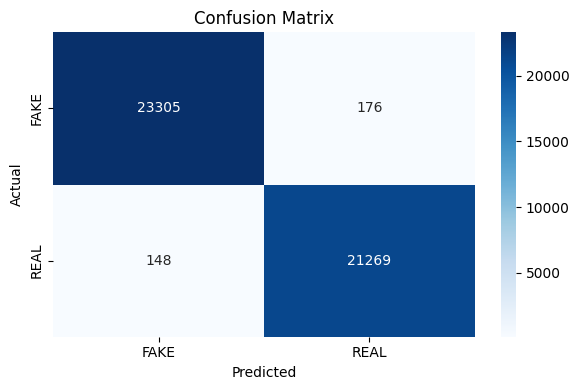

In [29]:

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["FAKE", "REAL"], yticklabels=["FAKE", "REAL"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

